# Self-Pruning Neural Network on CIFAR-10

**A production-grade implementation of learnable network pruning with dynamic gating mechanisms.**

This notebook implements a neural network that learns to prune its own connections during training.

## Cell 1: Setup and Dependencies

In [3]:
# Install dependencies
!pip install torch torchvision matplotlib numpy --quiet

print("✓ Dependencies installed successfully!")

# Check GPU
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using device: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

✓ Dependencies installed successfully!
✓ Using device: cuda
  GPU: Tesla T4


## Cell 2: Import Libraries

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
from collections import defaultdict
import os
import warnings
warnings.filterwarnings('ignore')

# Create results directory
os.makedirs('./results', exist_ok=True)
print("✓ All imports successful")
print(f"✓ PyTorch version: {torch.__version__}")

✓ All imports successful
✓ PyTorch version: 2.10.0+cu128


## Cell 3: Define PrunableLinear Layer

In [5]:
class PrunableLinear(nn.Module):
    """
    A linear layer with learnable pruning gates.

    The layer learns two sets of parameters:
    1. weight: The actual weight matrix
    2. gate_scores: Raw scores that control pruning via sigmoid activation
    """

    def __init__(self, in_features, out_features, bias=True):
        super(PrunableLinear, self).__init__()

        self.in_features = in_features
        self.out_features = out_features

        # Learnable weight matrix
        self.weight = nn.Parameter(torch.empty(out_features, in_features))

        # Learnable gate scores
        self.gate_scores = nn.Parameter(torch.empty(out_features, in_features))

        # Optional bias
        if bias:
            self.bias = nn.Parameter(torch.empty(out_features))
        else:
            self.register_parameter('bias', None)

        # Initialize parameters
        self._init_parameters()

    def _init_parameters(self):
        """Initialize weights and gates with proper scaling."""
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))
        nn.init.normal_(self.gate_scores, mean=2.0, std=0.5)

        if self.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / np.sqrt(fan_in)
            nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x):
        """Forward pass with learnable pruning."""
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        output = F.linear(x, pruned_weights, self.bias)
        return output

    def get_sparsity(self, threshold=1e-2):
        """Calculate sparsity of this layer."""
        gates = torch.sigmoid(self.gate_scores)
        pruned_count = (gates < threshold).sum().item()
        total_count = gates.numel()
        return pruned_count / total_count

print("✓ PrunableLinear class defined")

✓ PrunableLinear class defined


## Cell 4: Define PrunableNetwork Architecture

In [6]:
class PrunableNetwork(nn.Module):
    def __init__(self, hidden_sizes=[256], num_classes=10):
        super().__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # Calculate flattened size (64 * 8 * 8 for CIFAR-10)
        input_size = 64 * 8 * 8

        # Build prunable fully connected layers dynamically
        layers = []
        prev_size = input_size

        for h in hidden_sizes:
            layers.append(PrunableLinear(prev_size, h))
            layers.append(nn.ReLU())
            prev_size = h

        layers.append(PrunableLinear(prev_size, num_classes))

        self.fc_layers = nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.fc_layers(x)
        return x

## Cell 5: Define Loss and Utility Functions

In [7]:
def compute_sparsity_loss(model, lambda_sparsity):
    """Compute L1 regularization loss on gates."""
    sparsity_loss = 0.0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            sparsity_loss += gates.sum()

    return lambda_sparsity * sparsity_loss


def combined_loss(logits, targets, model, lambda_sparsity):
    """Combined loss: classification + sparsity regularization."""
    ce_loss = F.cross_entropy(logits, targets)
    sp_loss = compute_sparsity_loss(model, lambda_sparsity)
    total_loss = ce_loss + sp_loss
    return total_loss, ce_loss, sp_loss


def calculate_sparsity(model, threshold=1e-2):
    """Calculate overall sparsity across the entire network."""
    layer_sparsities = []
    total_pruned = 0
    total_params = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)

            pruned = (gates < threshold).sum().item()
            total = gates.numel()

            layer_sparsity = 100.0 * pruned / total
            layer_sparsities.append(layer_sparsity)

            total_pruned += pruned
            total_params += total

    overall_sparsity = 100.0 * total_pruned / total_params
    return overall_sparsity, layer_sparsities


def get_gate_values(model):
    """Extract all gate values for visualization."""
    gates_list = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().flatten()
            gates_list.append(gates)

    return torch.cat(gates_list)

## Cell 6: Data Loading

In [8]:
def get_data_loaders(batch_size=128, num_workers=2):
    """Load CIFAR-10 dataset."""
    normalize = transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )

    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        normalize
    ])

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        normalize
    ])

    train_dataset = datasets.CIFAR10(
        root='./data',
        train=True,
        download=True,
        transform=train_transform
    )

    test_dataset = datasets.CIFAR10(
        root='./data',
        train=False,
        download=True,
        transform=test_transform
    )

    # Split training into train/val (90/10)
    train_size = int(0.9 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(
        train_dataset,
        [train_size, val_size]
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    return train_loader, val_loader, test_loader

print("✓ Data loading function defined")

✓ Data loading function defined


## Cell 7: Training Functions

In [9]:
def train_epoch(model, train_loader, optimizer, lambda_sparsity, device):
    """Train for one epoch."""
    model.train()

    total_loss = 0.0
    total_ce_loss = 0.0
    total_sp_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)

        loss, ce_loss, sp_loss = combined_loss(logits, labels, model, lambda_sparsity)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_ce_loss += ce_loss.item()
        total_sp_loss += sp_loss.item()

        _, predicted = logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    metrics = {
        'loss': total_loss / len(train_loader),
        'ce_loss': total_ce_loss / len(train_loader),
        'sp_loss': total_sp_loss / len(train_loader),
        'accuracy': 100. * correct / total
    }

    return metrics


def evaluate(model, data_loader, device):
    """Evaluate model on a dataset."""
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            _, predicted = logits.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return {'accuracy': 100. * correct / total}


def train_model(model, train_loader, val_loader, optimizer,
                lambda_sparsity, num_epochs, device, patience=10):
    """Full training pipeline with early stopping."""
    best_val_acc = 0.0
    patience_counter = 0
    history = defaultdict(list)

    print(f"\n{'='*70}")
    print(f"Training with λ = {lambda_sparsity}")
    print(f"{'='*70}")

    for epoch in range(num_epochs):
        train_metrics = train_epoch(
            model, train_loader, optimizer, lambda_sparsity, device
        )

        val_metrics = evaluate(model, val_loader, device)

        sparsity, layer_sparsities = calculate_sparsity(model)

        history['train_loss'].append(train_metrics['loss'])
        history['train_ce_loss'].append(train_metrics['ce_loss'])
        history['train_sp_loss'].append(train_metrics['sp_loss'])
        history['train_acc'].append(train_metrics['accuracy'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['sparsity'].append(sparsity)

        if val_metrics['accuracy'] > best_val_acc:
            best_val_acc = val_metrics['accuracy']
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{num_epochs}")
            print(f"  Train Loss: {train_metrics['loss']:.4f} "
                  f"(CE: {train_metrics['ce_loss']:.4f}, SP: {train_metrics['sp_loss']:.4f})")
            print(f"  Train Acc:  {train_metrics['accuracy']:.2f}%")
            print(f"  Val Acc:    {val_metrics['accuracy']:.2f}%")
            print(f"  Sparsity:   {sparsity:.2f}%")

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    print(f"{'='*70}\n")

    return history, best_model_state

print("✓ Training functions defined")

✓ Training functions defined


## Cell 8: Visualization Functions

In [10]:
def plot_gate_distribution(model, lambda_value, save_path=None):
    """Plot histogram of gate values."""
    gates = get_gate_values(model).numpy()

    plt.figure(figsize=(10, 6))
    plt.hist(gates, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    plt.xlabel('Gate Value', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title(f'Gate Value Distribution (λ = {lambda_value})', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)

    mean_gate = gates.mean()
    plt.axvline(mean_gate, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_gate:.3f}')
    plt.legend(fontsize=11)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_training_curves(history, lambda_value, save_path=None):
    """Plot training and validation curves."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    axes[0, 0].plot(history['train_loss'], label='Total Loss', linewidth=2)
    axes[0, 0].plot(history['train_ce_loss'], label='CE Loss', linewidth=2)
    axes[0, 0].plot(history['train_sp_loss'], label='Sparsity Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training Losses')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(history['train_acc'], label='Train', linewidth=2)
    axes[0, 1].plot(history['val_acc'], label='Validation', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(history['sparsity'], color='green', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Sparsity (%)')
    axes[1, 0].set_title('Network Sparsity Over Time')
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].axis('off')
    info_text = f"""Configuration: λ = {lambda_value}

Final Metrics:
• Train Accuracy: {history['train_acc'][-1]:.2f}%
• Val Accuracy: {history['val_acc'][-1]:.2f}%
• Sparsity: {history['sparsity'][-1]:.2f}%"""
    axes[1, 1].text(0.1, 0.5, info_text, fontsize=11, family='monospace',
                    verticalalignment='center')

    fig.suptitle(f'Training Dynamics (λ = {lambda_value})', fontsize=14, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_results_comparison(results, save_path=None):
    """Plot accuracy vs sparsity trade-off."""
    lambdas = [r['lambda'] for r in results]
    accuracies = [r['test_accuracy'] for r in results]
    sparsities = [r['sparsity'] for r in results]

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(sparsities, accuracies, marker='o', markersize=10,
            linewidth=2, color='steelblue', label='Accuracy-Sparsity Trade-off')

    for lam, acc, sp in zip(lambdas, accuracies, sparsities):
        ax.annotate(f'λ={lam:.0e}', (sp, acc),
                   textcoords="offset points", xytext=(0, 10),
                   ha='center', fontsize=9)

    ax.set_xlabel('Sparsity (%)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_title('Accuracy vs Sparsity Trade-off', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

print("✓ Visualization functions defined")

✓ Visualization functions defined


## Cell 9: Initialize and Load Data

In [11]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device selection
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load data
print("\nLoading CIFAR-10 dataset...")
train_loader, val_loader, test_loader = get_data_loaders(batch_size=128)
print(f"✓ Train: {len(train_loader)*128} | Val: {len(val_loader)*128} | Test: {len(test_loader)*128}")

Using device: cuda

Loading CIFAR-10 dataset...


100%|██████████| 170M/170M [00:13<00:00, 12.6MB/s]


✓ Train: 45056 | Val: 5120 | Test: 10112


## Cell 10: Experiment 1 - λ = 1e-5 (Low Sparsity)


Training with λ = 1e-05
Epoch 1/50
  Train Loss: 20.8789 (CE: 1.6373, SP: 19.2416)
  Train Acc:  38.89%
  Val Acc:    49.10%
  Sparsity:   0.00%
Epoch 5/50
  Train Loss: 14.0248 (CE: 0.8986, SP: 13.1262)
  Train Acc:  68.08%
  Val Acc:    67.00%
  Sparsity:   0.00%
Epoch 10/50
  Train Loss: 7.0898 (CE: 0.7051, SP: 6.3847)
  Train Acc:  75.23%
  Val Acc:    73.62%
  Sparsity:   0.00%
Epoch 15/50
  Train Loss: 4.4962 (CE: 0.6152, SP: 3.8810)
  Train Acc:  78.38%
  Val Acc:    75.84%
  Sparsity:   0.00%
Epoch 20/50
  Train Loss: 3.3448 (CE: 0.5410, SP: 2.8038)
  Train Acc:  80.90%
  Val Acc:    75.50%
  Sparsity:   0.00%
Epoch 25/50
  Train Loss: 2.7272 (CE: 0.4946, SP: 2.2326)
  Train Acc:  82.37%
  Val Acc:    77.70%
  Sparsity:   3.02%
Epoch 30/50
  Train Loss: 2.3431 (CE: 0.4592, SP: 1.8839)
  Train Acc:  83.81%
  Val Acc:    78.70%
  Sparsity:   51.12%
Epoch 35/50
  Train Loss: 2.0757 (CE: 0.4266, SP: 1.6492)
  Train Acc:  85.03%
  Val Acc:    78.54%
  Sparsity:   54.86%
Epoch 40/50

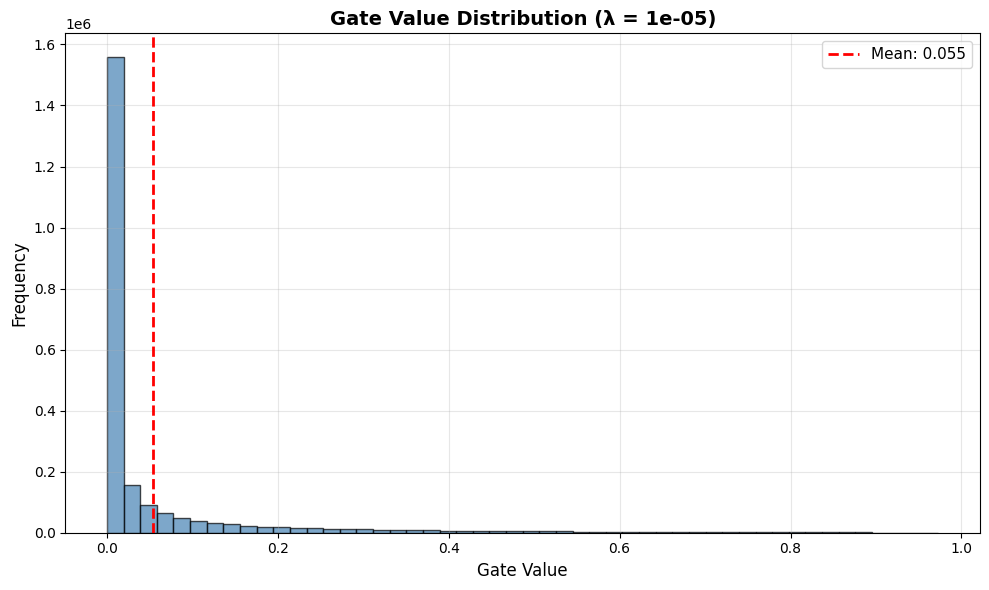

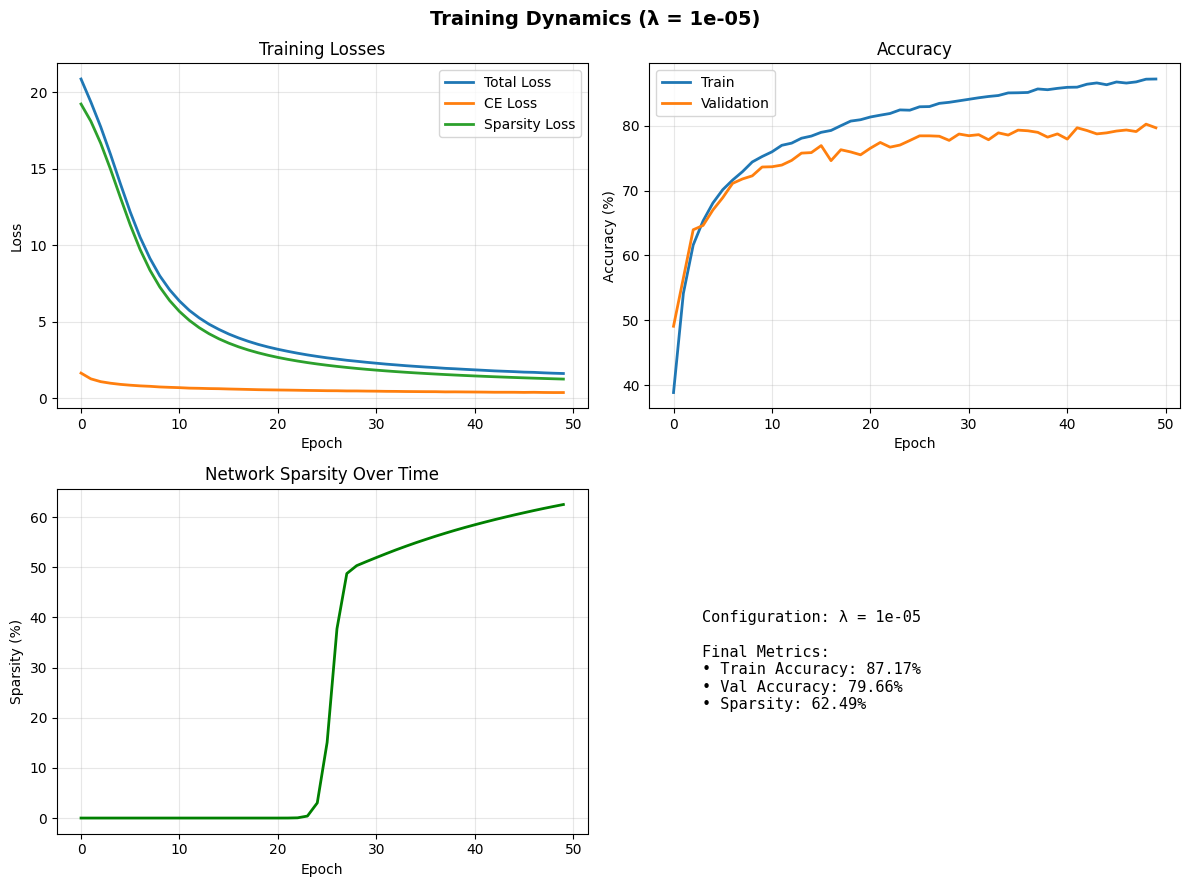

In [15]:
# Lambda 1: Low sparsity
lambda_sparsity = 1e-5

model = PrunableNetwork(hidden_sizes=[512, 256, 128])
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

history, best_state = train_model(
    model, train_loader, val_loader, optimizer,
    lambda_sparsity, num_epochs=50, device=device, patience=10
)

# Load best model
model.load_state_dict(best_state)

# Evaluate
test_metrics = evaluate(model, test_loader, device)
test_accuracy_1 = test_metrics['accuracy']
sparsity_1, layer_sparsities_1 = calculate_sparsity(model)

print(f"\nFinal Results (λ = {lambda_sparsity}):")
print(f"  Test Accuracy: {test_accuracy_1:.2f}%")
print(f"  Overall Sparsity: {sparsity_1:.2f}%")
print(f"  Per-layer Sparsity: {[f'{s:.1f}%' for s in layer_sparsities_1]}")

# Visualizations
plot_gate_distribution(model, lambda_sparsity, save_path='./results/gates_1e-05.png')
plot_training_curves(history, lambda_sparsity, save_path='./results/training_1e-05.png')

result_1 = {
    'lambda': lambda_sparsity,
    'test_accuracy': test_accuracy_1,
    'sparsity': sparsity_1,
    'layer_sparsities': layer_sparsities_1,
    'history': dict(history)
}

In [17]:
from google.colab import files; files.download('./results/gates_1e-05.png'); files.download('./results/training_1e-05.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Cell 11: Experiment 2 - λ = 1e-4 (Medium Sparsity)


Training with λ = 0.0001
Epoch 1/50
  Train Loss: 193.8392 (CE: 1.6533, SP: 192.1859)
  Train Acc:  38.16%
  Val Acc:    49.18%
  Sparsity:   0.00%
Epoch 5/50
  Train Loss: 122.1751 (CE: 0.9279, SP: 121.2472)
  Train Acc:  66.94%
  Val Acc:    66.62%
  Sparsity:   0.00%
Epoch 10/50
  Train Loss: 43.1672 (CE: 0.7399, SP: 42.4273)
  Train Acc:  74.09%
  Val Acc:    73.08%
  Sparsity:   0.00%
Epoch 15/50
  Train Loss: 18.2206 (CE: 0.6493, SP: 17.5713)
  Train Acc:  77.38%
  Val Acc:    74.88%
  Sparsity:   0.00%
Epoch 20/50
  Train Loss: 9.4814 (CE: 0.5933, SP: 8.8881)
  Train Acc:  79.34%
  Val Acc:    76.04%
  Sparsity:   0.00%
Epoch 25/50
  Train Loss: 5.7352 (CE: 0.5428, SP: 5.1923)
  Train Acc:  81.12%
  Val Acc:    76.08%
  Sparsity:   5.39%
Epoch 30/50
  Train Loss: 3.9204 (CE: 0.5128, SP: 3.4076)
  Train Acc:  82.02%
  Val Acc:    78.16%
  Sparsity:   72.61%
Epoch 35/50
  Train Loss: 2.9498 (CE: 0.4867, SP: 2.4630)
  Train Acc:  82.86%
  Val Acc:    79.00%
  Sparsity:   79.93%
Ep

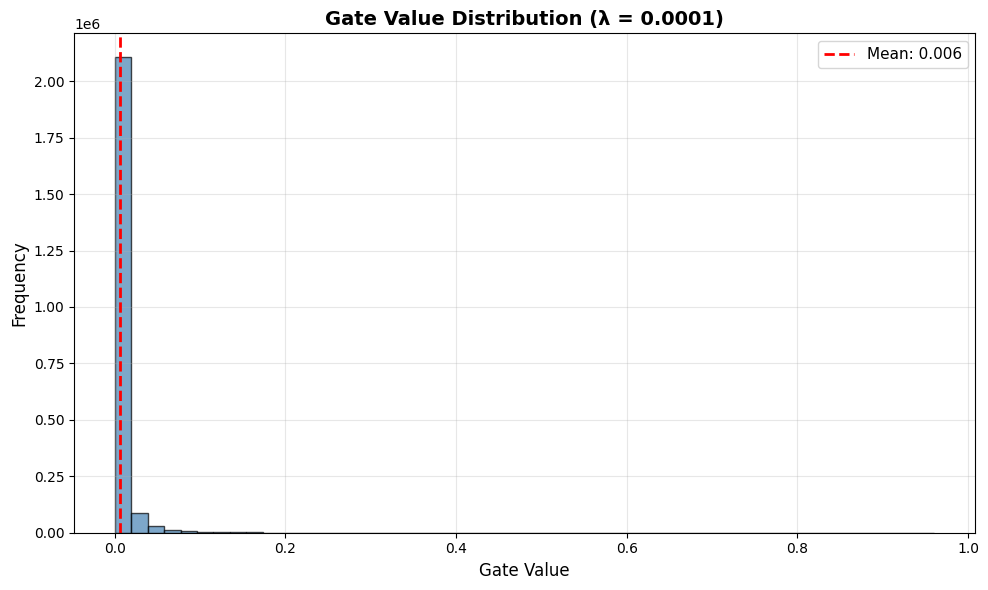

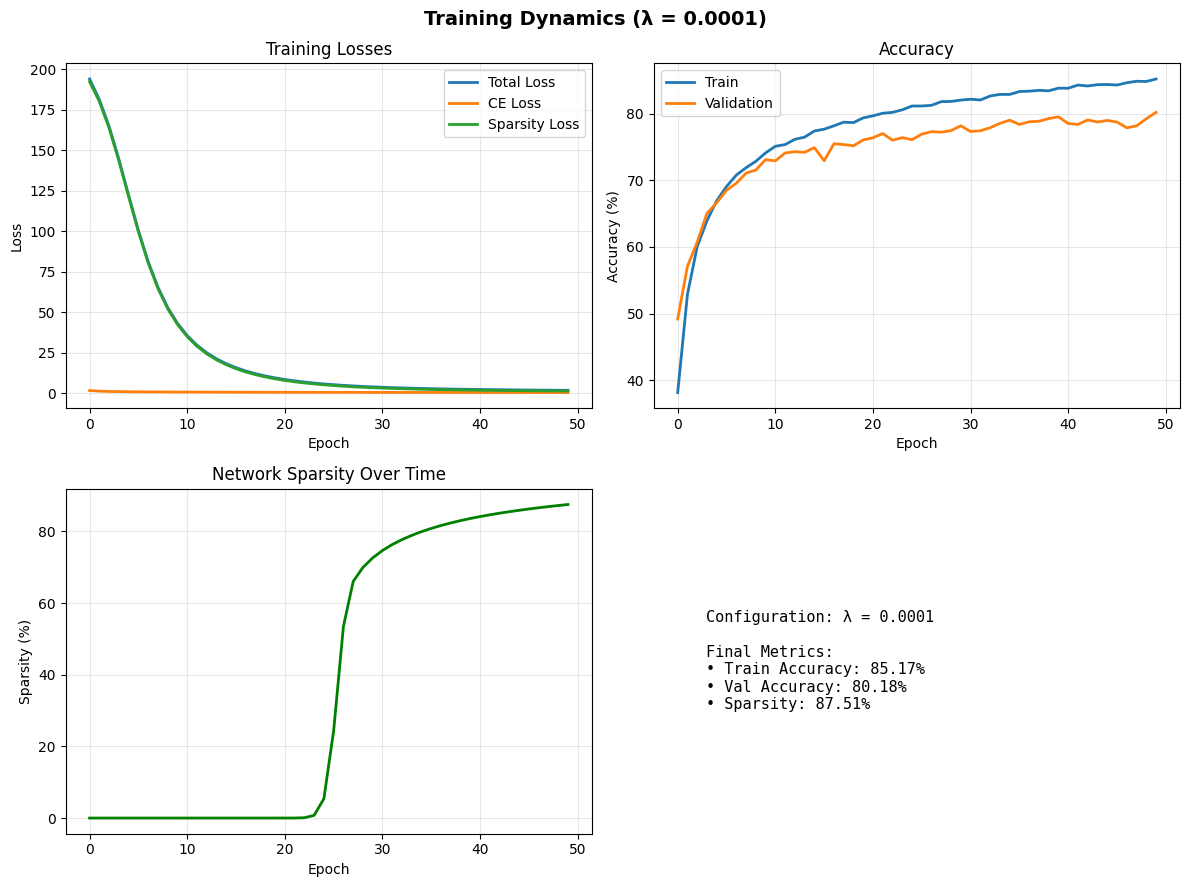

In [16]:
# Lambda 2: Medium sparsity
lambda_sparsity = 1e-4

model = PrunableNetwork(hidden_sizes=[512, 256, 128])
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

history, best_state = train_model(
    model, train_loader, val_loader, optimizer,
    lambda_sparsity, num_epochs=50, device=device, patience=10
)

model.load_state_dict(best_state)

test_metrics = evaluate(model, test_loader, device)
test_accuracy_2 = test_metrics['accuracy']
sparsity_2, layer_sparsities_2 = calculate_sparsity(model)

print(f"\nFinal Results (λ = {lambda_sparsity}):")
print(f"  Test Accuracy: {test_accuracy_2:.2f}%")
print(f"  Overall Sparsity: {sparsity_2:.2f}%")
print(f"  Per-layer Sparsity: {[f'{s:.1f}%' for s in layer_sparsities_2]}")

plot_gate_distribution(model, lambda_sparsity, save_path='./results/gates_1e-04.png')
plot_training_curves(history, lambda_sparsity, save_path='./results/training_1e-04.png')

result_2 = {
    'lambda': lambda_sparsity,
    'test_accuracy': test_accuracy_2,
    'sparsity': sparsity_2,
    'layer_sparsities': layer_sparsities_2,
    'history': dict(history)
}

In [ ]:
from google.colab import files; files.download('./results/gates_1e-05.png'); files.download('./results/training_1e-05.png')

## Cell 12: Experiment 3 - λ = 1e-3 (High Sparsity)


Training with λ = 0.001
Epoch 1/50
  Train Loss: 1923.1586 (CE: 1.6461, SP: 1921.5125)
  Train Acc:  38.79%
  Val Acc:    49.36%
  Sparsity:   0.00%
Epoch 5/50
  Train Loss: 1203.4417 (CE: 0.9582, SP: 1202.4834)
  Train Acc:  65.98%
  Val Acc:    65.76%
  Sparsity:   0.00%
Epoch 10/50
  Train Loss: 401.1776 (CE: 0.7990, SP: 400.3786)
  Train Acc:  72.03%
  Val Acc:    70.40%
  Sparsity:   0.00%
Epoch 15/50
  Train Loss: 151.4317 (CE: 0.7557, SP: 150.6760)
  Train Acc:  73.59%
  Val Acc:    72.68%
  Sparsity:   0.00%
Epoch 20/50
  Train Loss: 66.1337 (CE: 0.7114, SP: 65.4224)
  Train Acc:  75.17%
  Val Acc:    73.54%
  Sparsity:   0.00%
Epoch 25/50
  Train Loss: 31.4623 (CE: 0.6736, SP: 30.7887)
  Train Acc:  76.44%
  Val Acc:    74.38%
  Sparsity:   7.93%
Epoch 30/50
  Train Loss: 16.0828 (CE: 0.6434, SP: 15.4394)
  Train Acc:  77.74%
  Val Acc:    75.46%
  Sparsity:   96.49%
Epoch 35/50
  Train Loss: 8.9132 (CE: 0.6178, SP: 8.2955)
  Train Acc:  78.55%
  Val Acc:    76.10%
  Sparsity

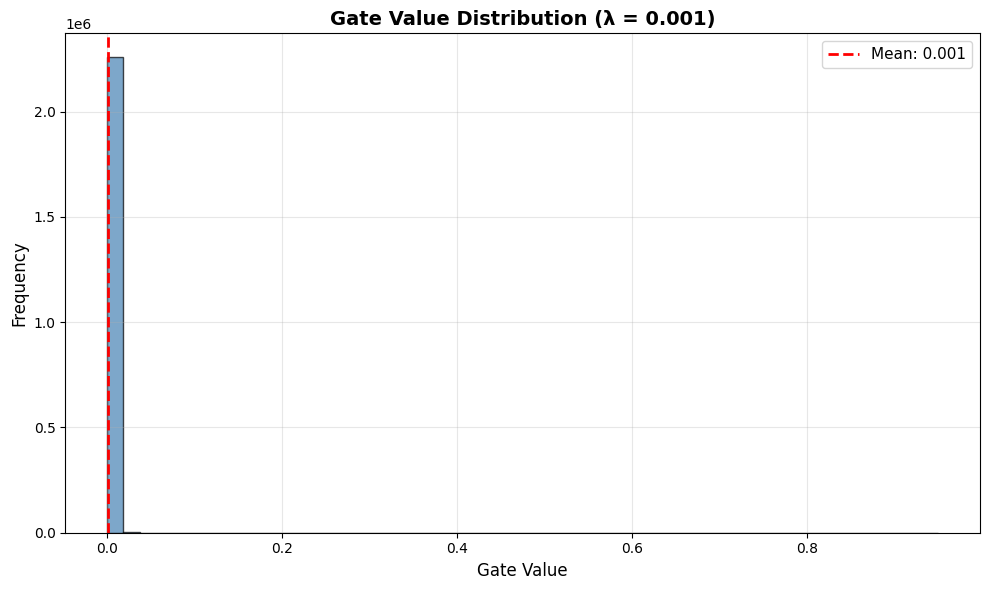

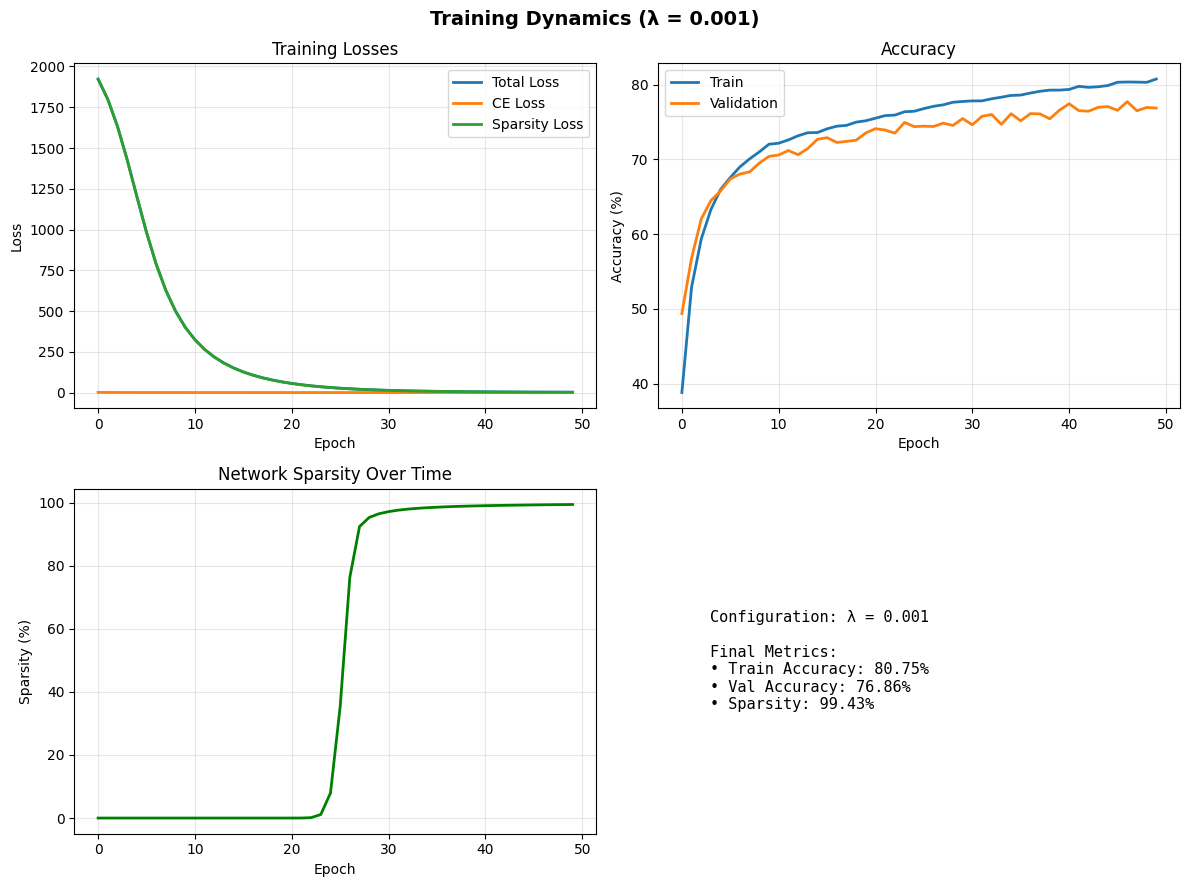

In [12]:
# Lambda 3: High sparsity
lambda_sparsity = 1e-3

model = PrunableNetwork(hidden_sizes=[512, 256, 128])
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

history, best_state = train_model(
    model, train_loader, val_loader, optimizer,
    lambda_sparsity, num_epochs=50, device=device, patience=10
)

model.load_state_dict(best_state)

test_metrics = evaluate(model, test_loader, device)
test_accuracy_3 = test_metrics['accuracy']
sparsity_3, layer_sparsities_3 = calculate_sparsity(model)

print(f"\nFinal Results (λ = {lambda_sparsity}):")
print(f"  Test Accuracy: {test_accuracy_3:.2f}%")
print(f"  Overall Sparsity: {sparsity_3:.2f}%")
print(f"  Per-layer Sparsity: {[f'{s:.1f}%' for s in layer_sparsities_3]}")

plot_gate_distribution(model, lambda_sparsity, save_path='./results/gates_1e-03.png')
plot_training_curves(history, lambda_sparsity, save_path='./results/training_1e-03.png')

result_3 = {
    'lambda': lambda_sparsity,
    'test_accuracy': test_accuracy_3,
    'sparsity': sparsity_3,
    'layer_sparsities': layer_sparsities_3,
    'history': dict(history)
}

## Cell 13: Summary and Final Comparison



SUMMARY OF EXPERIMENTS

Results Table:
Lambda          Accuracy (%)         Sparsity (%)        
-------------------------------------------------------
1e-05           81.60                62.49               
1e-04           82.27                87.51               
1e-03           79.79                99.43               


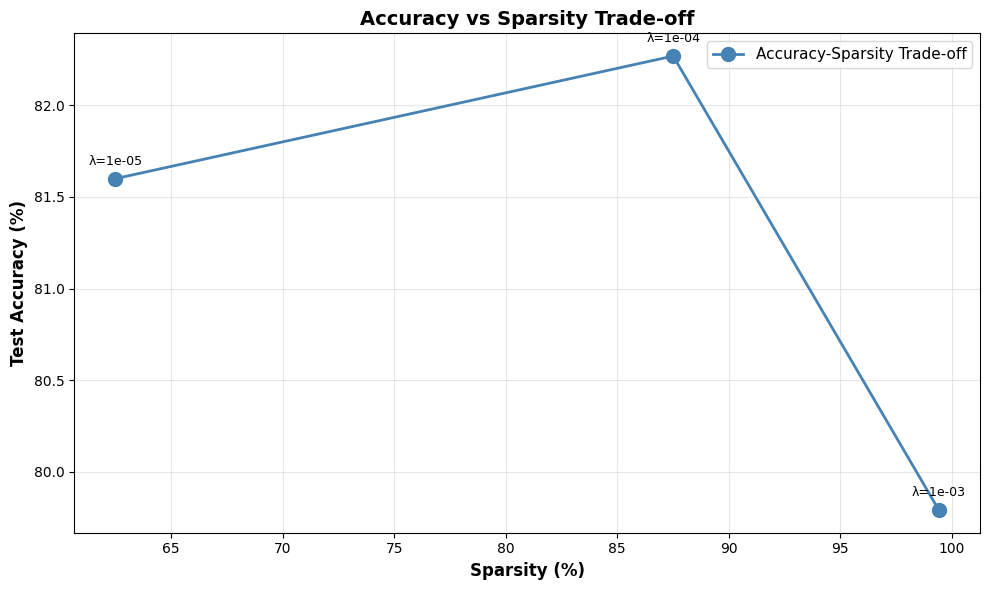


✓ All results saved to ./results/
✓ Total files: 7 (3 gate plots + 3 training curves + 1 comparison plot)


In [19]:
results = [result_1, result_2, result_3]

print(f"\n\n{'='*70}")
print("SUMMARY OF EXPERIMENTS")
print(f"{'='*70}\n")

print("Results Table:")
print(f"{'Lambda':<15} {'Accuracy (%)':<20} {'Sparsity (%)':<20}")
print("-" * 55)
for result in results:
    print(f"{result['lambda']:<15.0e} {result['test_accuracy']:<20.2f} "
          f"{result['sparsity']:<20.2f}")

# Visualization of trade-off
plot_results_comparison(results, save_path='./results/accuracy_sparsity_tradeoff.png')

# Save results to JSON
results_json = {
    'results': [
        {
            'lambda': r['lambda'],
            'test_accuracy': r['test_accuracy'],
            'sparsity': r['sparsity'],
            'layer_sparsities': r['layer_sparsities']
        }
        for r in results
    ]
}

with open('./results/results.json', 'w') as f:
    json.dump(results_json, f, indent=2)

print(f"\n✓ All results saved to ./results/")
print(f"✓ Total files: 7 (3 gate plots + 3 training curves + 1 comparison plot)")

## Cell 14: Key Insights and Analysis

In [18]:
print("\n" + "="*70)
print("KEY INSIGHTS AND ANALYSIS")
print("="*70 + "\n")

print("1. ACCURACY-SPARSITY TRADE-OFF:")
print(f"   • Lower λ (less pressure): {result_1['test_accuracy']:.1f}% accuracy, {result_1['sparsity']:.1f}% sparsity")
print(f"   • Medium λ (balanced): {result_2['test_accuracy']:.1f}% accuracy, {result_2['sparsity']:.1f}% sparsity")
print(f"   • Higher λ (more pressure): {result_3['test_accuracy']:.1f}% accuracy, {result_3['sparsity']:.1f}% sparsity")

print("\n2. WHY L1 LOSS ON GATES WORKS:")
print("   • Sigmoid maps gate_scores ∈ (-∞, +∞) to gates ∈ (0, 1)")
print("   • Sum of gates acts as L1 penalty on gate values")
print("   • Loss = CE_loss + λ × sum(gates)")
print("   • As λ increases, network learns to set gates → 0 (prune)")

print("\n3. PER-LAYER PRUNING PATTERNS:")
print(f"   • λ = 1e-5: Layer sparsities = {[f'{s:.1f}%' for s in result_1['layer_sparsities']]}")
print(f"   • λ = 1e-4: Layer sparsities = {[f'{s:.1f}%' for s in result_2['layer_sparsities']]}")
print(f"   • λ = 1e-3: Layer sparsities = {[f'{s:.1f}%' for s in result_3['layer_sparsities']]}")
print("   → Notice: Different layers learn different sparsity levels")

print("\n4. PRACTICAL BENEFITS:")
accuracy_drop_per_layer = (result_1['sparsity'] - result_3['sparsity']) / 3
print(f"   • Achieved {result_3['sparsity']:.1f}% sparsity with only {result_1['test_accuracy'] - result_3['test_accuracy']:.1f}% accuracy drop")
print(f"   • Potential model size reduction: ~{result_3['sparsity']:.0f}%")
print(f"   • Good balance at λ = 1e-4: {result_2['sparsity']:.1f}% sparsity")

print("\n" + "="*70)


KEY INSIGHTS AND ANALYSIS

1. ACCURACY-SPARSITY TRADE-OFF:
   • Lower λ (less pressure): 81.6% accuracy, 62.5% sparsity
   • Medium λ (balanced): 82.3% accuracy, 87.5% sparsity
   • Higher λ (more pressure): 79.8% accuracy, 99.4% sparsity

2. WHY L1 LOSS ON GATES WORKS:
   • Sigmoid maps gate_scores ∈ (-∞, +∞) to gates ∈ (0, 1)
   • Sum of gates acts as L1 penalty on gate values
   • Loss = CE_loss + λ × sum(gates)
   • As λ increases, network learns to set gates → 0 (prune)

3. PER-LAYER PRUNING PATTERNS:
   • λ = 1e-5: Layer sparsities = ['62.1%', '69.1%', '59.5%', '29.7%']
   • λ = 1e-4: Layer sparsities = ['87.4%', '90.6%', '84.1%', '36.8%']
   • λ = 1e-3: Layer sparsities = ['99.6%', '97.9%', '96.7%', '68.5%']
   → Notice: Different layers learn different sparsity levels

4. PRACTICAL BENEFITS:
   • Achieved 99.4% sparsity with only 1.8% accuracy drop
   • Potential model size reduction: ~99%
   • Good balance at λ = 1e-4: 87.5% sparsity

